In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('datos/datos_modelo1/raw/aldimi_demand_dataset.csv')
df.head()

,fecha,dia_semana,es_fin_de_semana,n_total,n_low,n_medium,n_high,n_presentes,N02BE_demand,N05B_demand,M01AB_demand,total_demand
0,2014-01-02,3,0,103,63,24,16,103,222.17,15.35,0.12,237.64
1,2014-01-03,4,0,104,64,24,16,104,347.97,35.60,25.48,409.05
2,2014-01-04,5,1,101,60,26,15,65,268.73,19.84,6.37,294.94
3,2014-01-05,6,1,101,60,26,15,69,187.14,16.71,12.45,216.30
4,2014-01-06,0,0,100,60,26,14,100,147.13,37.07,13.49,197.69


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
dia_semana,2106.0,3.000475,2.000831,0.0,1.0000,3.000,5.000,6.00
es_fin_de_semana,2106.0,0.285850,0.451926,0.0,0.0000,0.000,1.000,1.00
n_total,2106.0,102.430674,2.245754,95.0,101.0000,103.000,104.000,108.00
n_low,2106.0,50.519943,5.582023,35.0,47.0000,51.000,54.000,66.00
n_medium,2106.0,29.347104,4.441612,18.0,26.0000,29.000,32.000,42.00
n_high,2106.0,22.563628,4.410201,11.0,20.0000,22.000,26.000,36.00
n_presentes,2106.0,94.003324,13.636178,62.0,78.0000,101.000,104.000,108.00
N02BE_demand,2106.0,186.218319,95.660627,0.0,116.0725,169.180,240.590,1120.32
N05B_demand,2106.0,25.499103,16.034609,0.0,13.7750,23.025,33.555,177.22
M01AB_demand,2106.0,23.122236,13.495381,0.0,13.2500,21.050,30.570,96.32


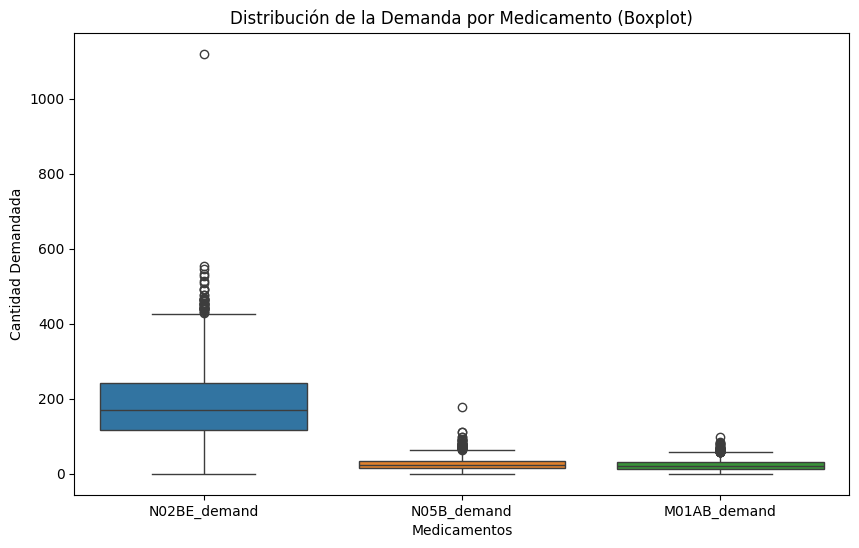

In [ ]:
columnas_demanda = ['N02BE_demand', 'N05B_demand', 'M01AB_demand']

plt.figure(figsize=(10, 6))

sns.boxplot(data=df[columnas_demanda])

plt.title('Distribución de la Demanda por Medicamento (Boxplot)')
plt.ylabel('Cantidad Demandada')
plt.xlabel('Medicamentos')

# Mostrar el gráfico
plt.show()

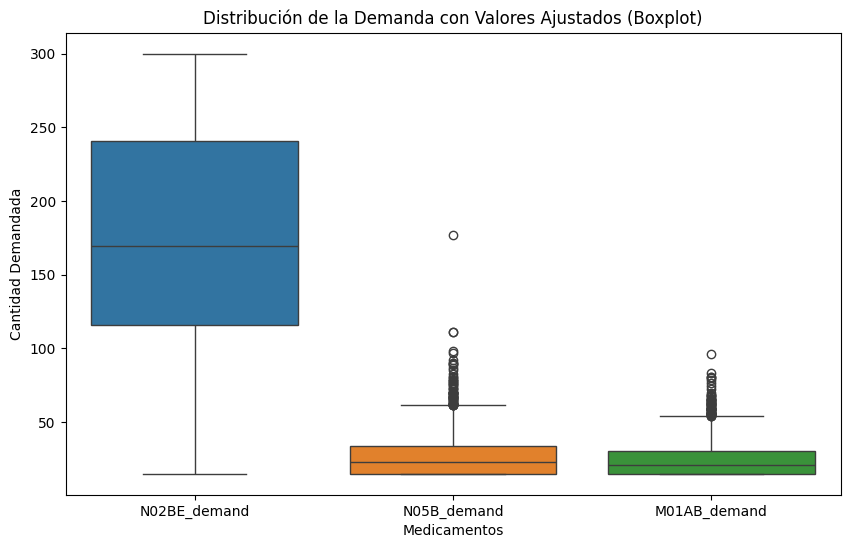

In [8]:

df[columnas_demanda] = df[columnas_demanda].clip(lower=15, upper=300)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[columnas_demanda])

plt.title('Distribución de la Demanda con Valores Ajustados (Boxplot)')
plt.ylabel('Cantidad Demandada')
plt.xlabel('Medicamentos')
plt.show()

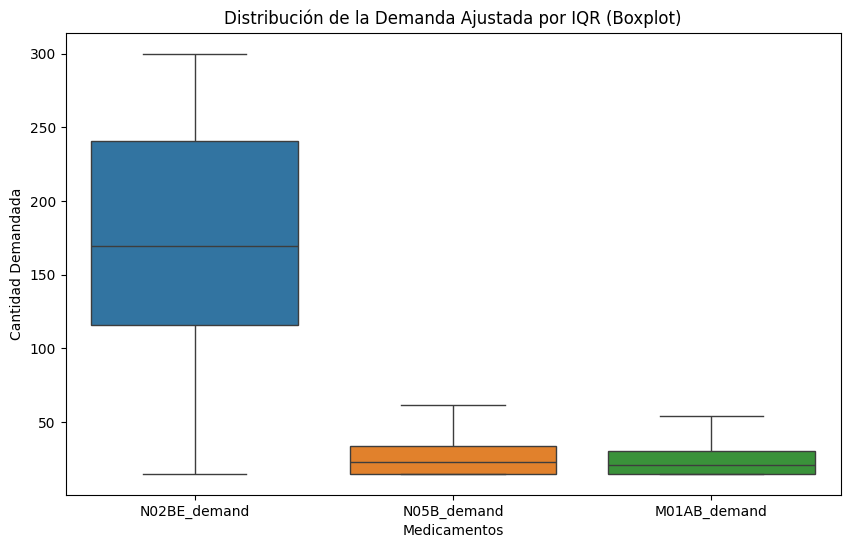

In [9]:
for col in columnas_demanda:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[columnas_demanda])

plt.title('Distribución de la Demanda Ajustada por IQR (Boxplot)')
plt.ylabel('Cantidad Demandada')
plt.xlabel('Medicamentos')
plt.show()

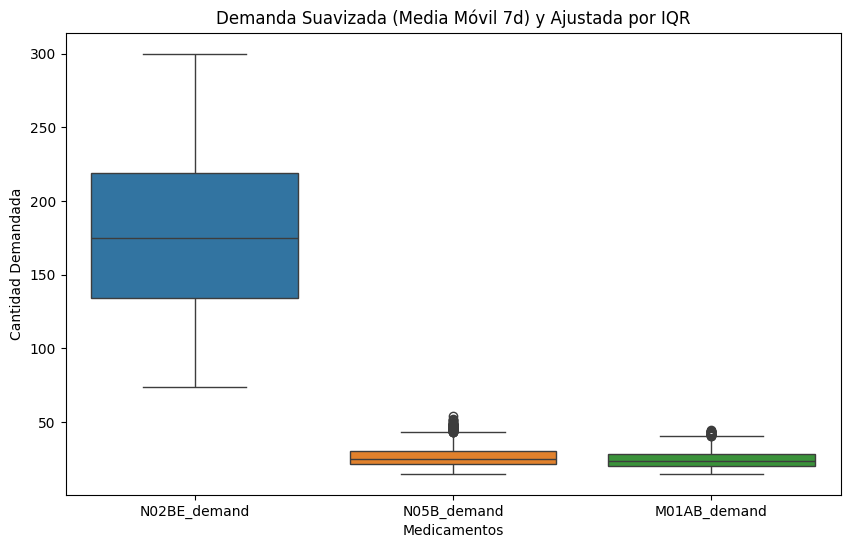

In [11]:
df[columnas_demanda] = df[columnas_demanda].rolling(window=7, min_periods=1).mean()
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[columnas_demanda])

plt.title('Demanda Suavizada (Media Móvil 7d) y Ajustada por IQR')
plt.ylabel('Cantidad Demandada')
plt.xlabel('Medicamentos')
plt.show()

In [ ]:
df.to_csv('../datos/datos_modelo1/raw/aldimi_demand_avanzado.csv', index=False)